In [1]:
import numpy as np
import scvelo as scv
import scanpy as sc
import pandas as pd
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = ''
DATA_NAME = 'stereo-seq-lung'

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/{DATA_NAME}-out.h5ad')

# Time and Cell Velocity

In [11]:
stream_plot_config = {
    'width': 3,
    'markersize': 60,
    'density': 2,
    'linewidth': 1,
    'arrow_size': 0.8,
}

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:02) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


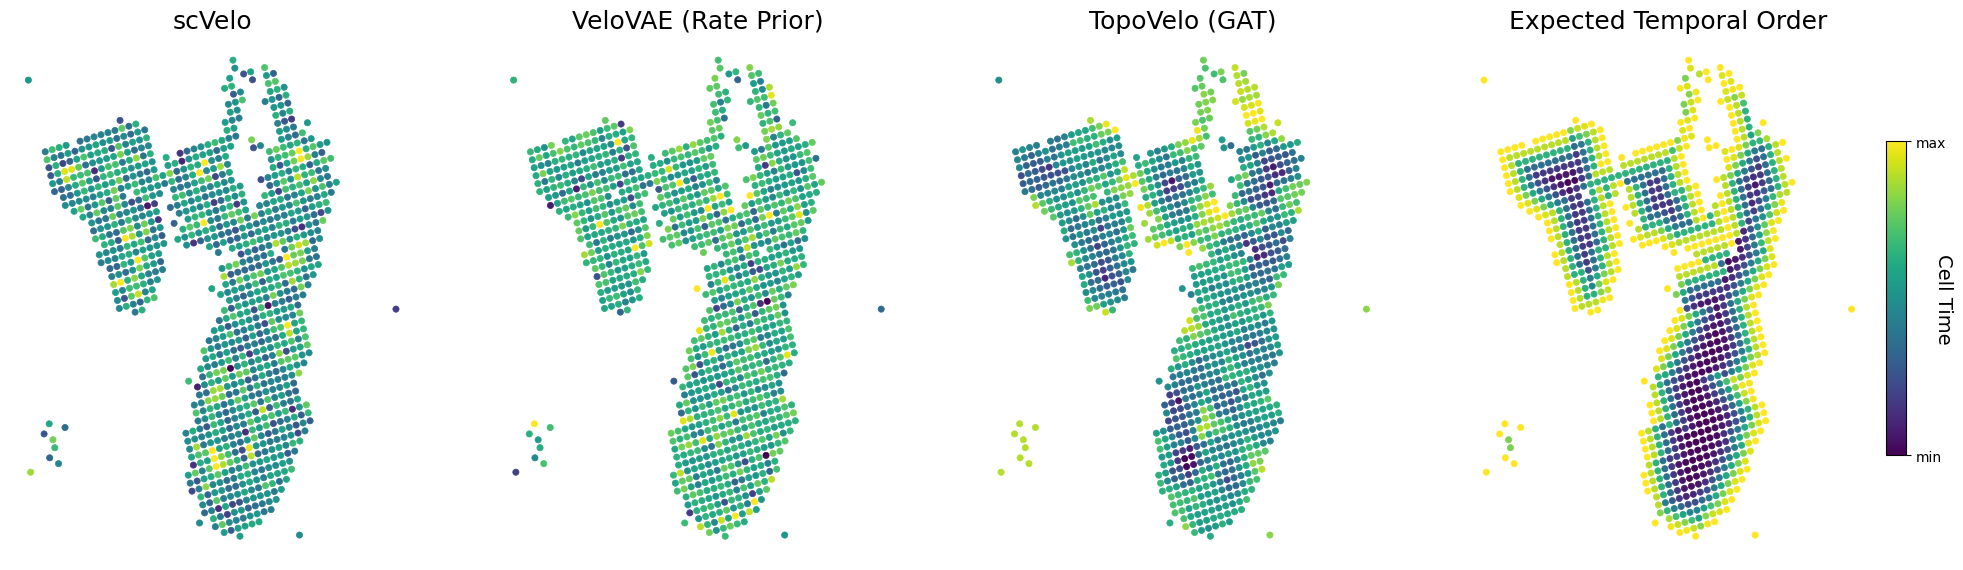

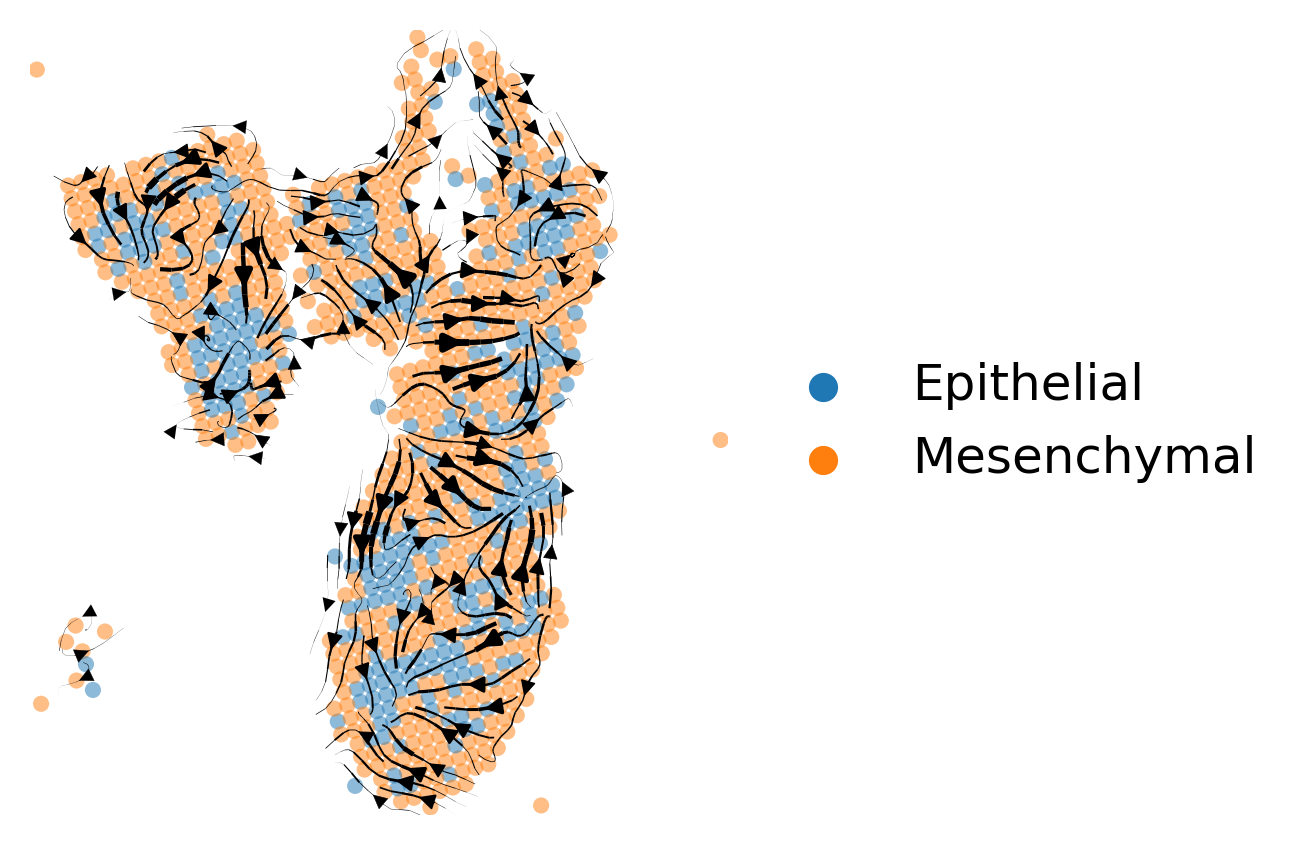

Overwriting the original KNN graph! (.uns, .obsp)


Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'fullvb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'fullvb_velocity_spatial', embedded velocity vectors (adata.obsm)


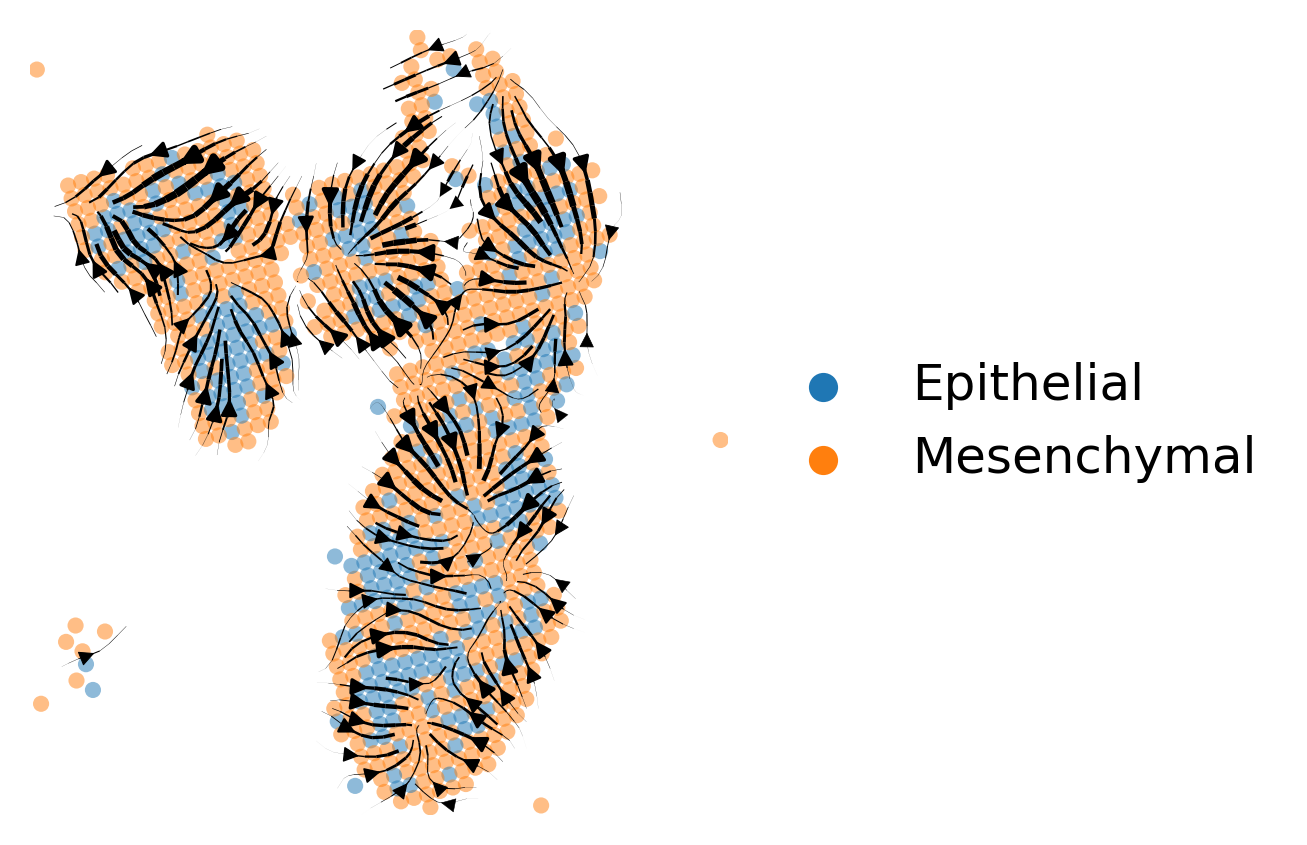

Overwriting the original KNN graph! (.uns, .obsp)


Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


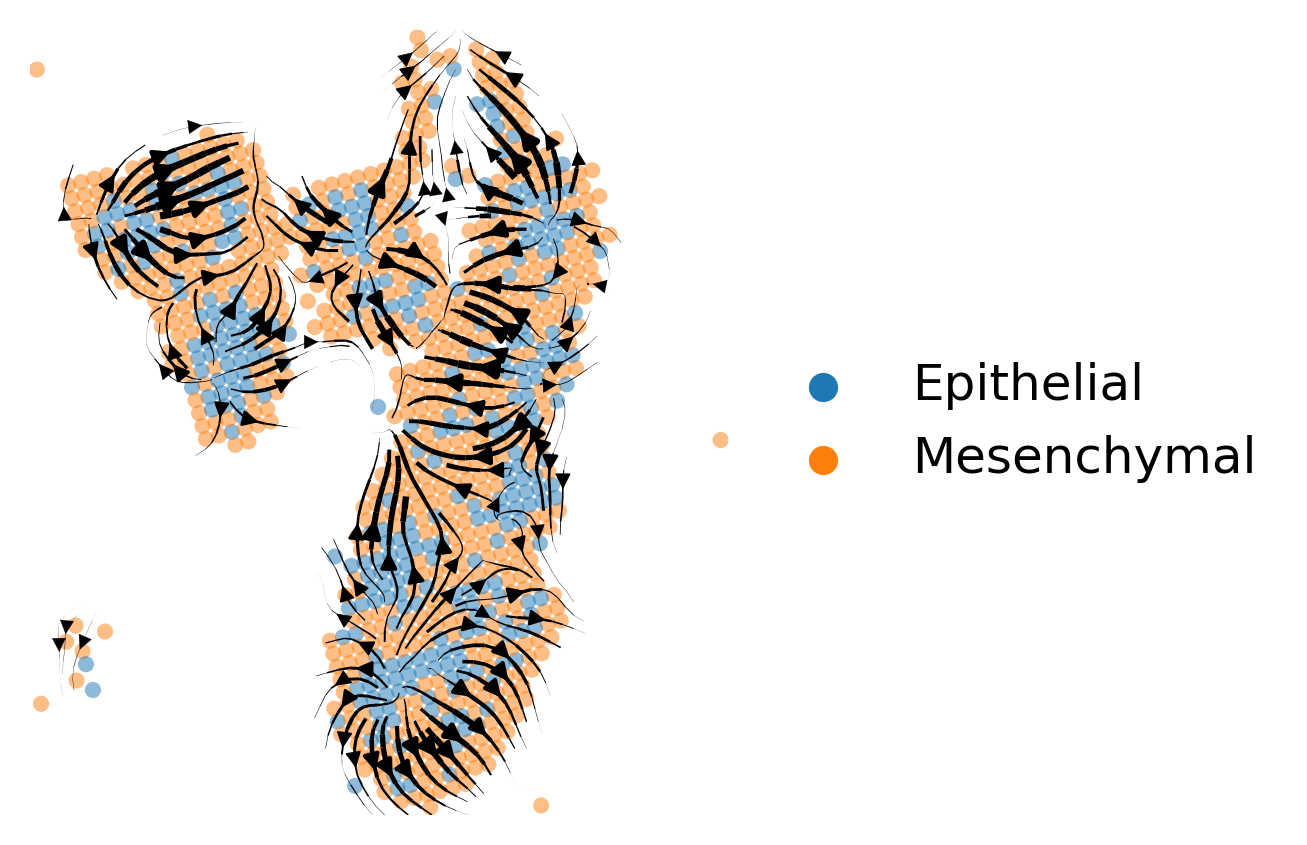

In [12]:
_ = tpv.post_analysis(
    adata,
    'lung',
    ['scVelo', 'VeloVAE (Rate Prior)', 'TopoVelo (GAT)'],
    ['fit', 'fullvb', 'gat'],
    plot_type=['time', 'cell velocity'],
    stream_plot_config=stream_plot_config,
    dpi=300
)

# Velocity on UMAP

In [11]:
stream_plot_config = {
    'width': 3,
    'markersize': 60,
    'density': 2,
    'linewidth': 1,
    'arrow_size': 0.8,
}

In [14]:
sc.tl.umap(adata, min_dist=0.05)

---   Plotting  Results   ---
computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


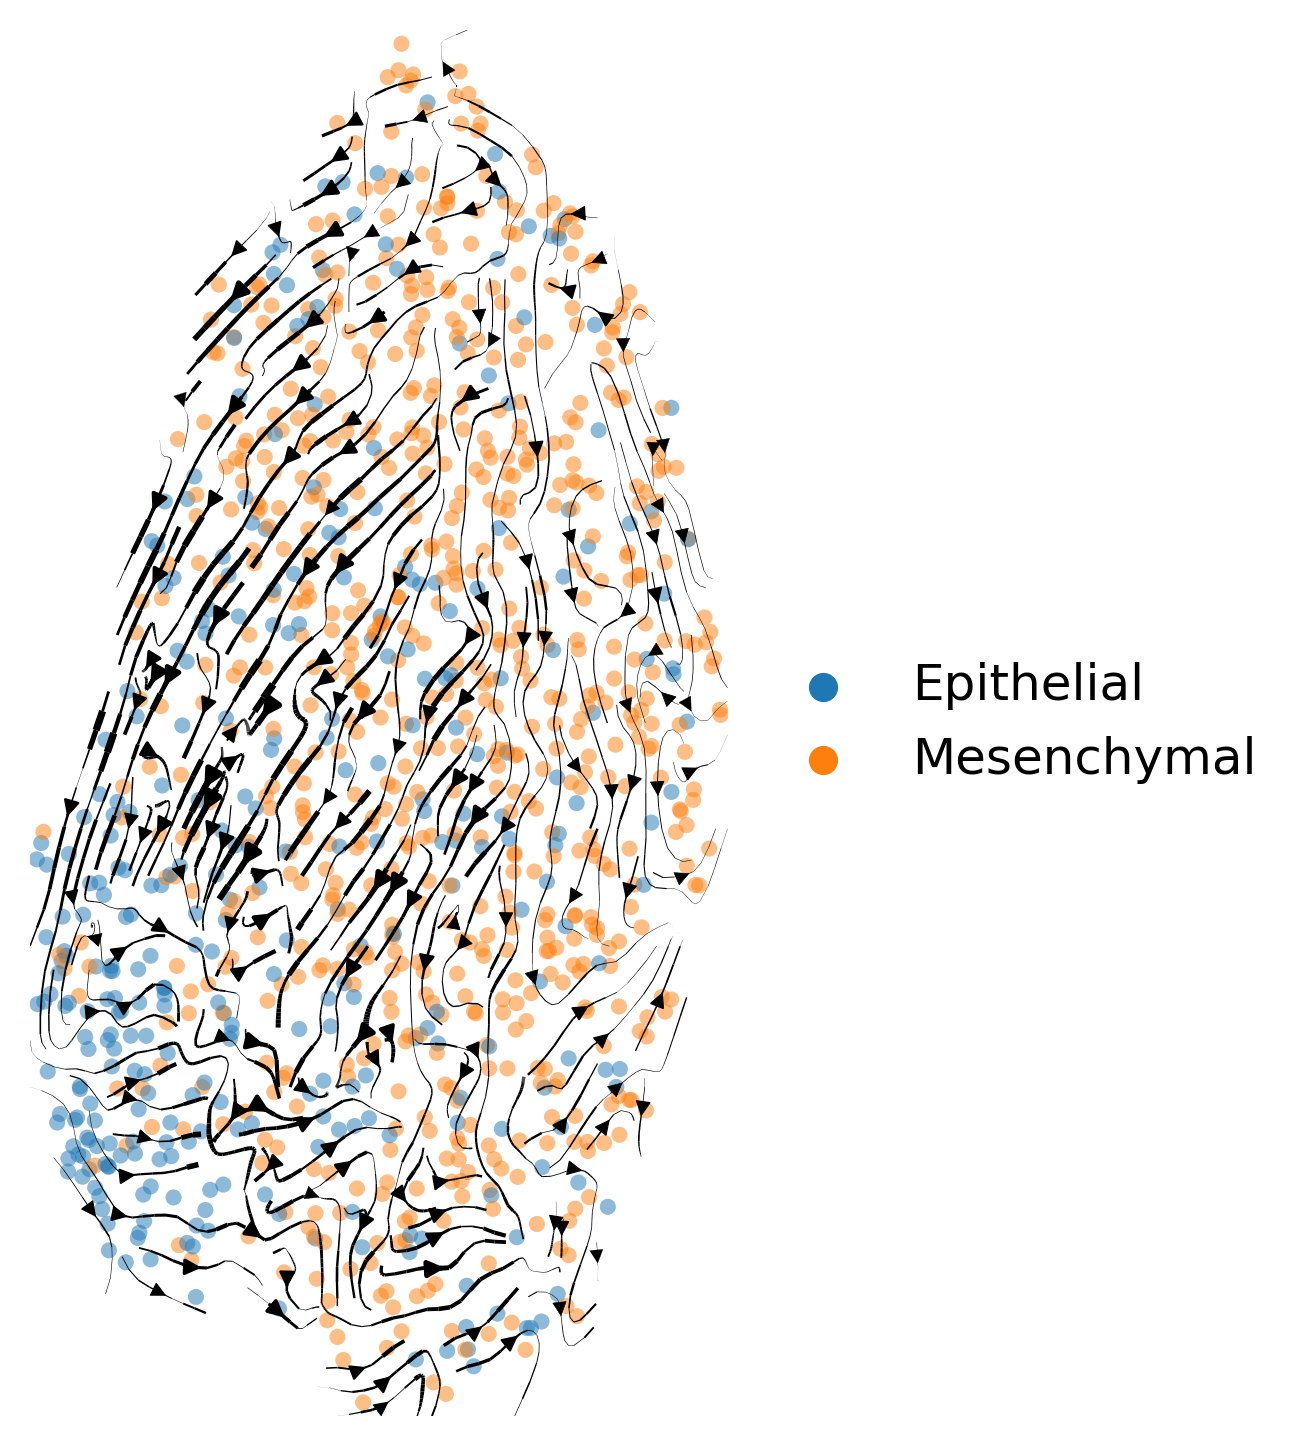

computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'fullvb_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'fullvb_velocity_umap', embedded velocity vectors (adata.obsm)


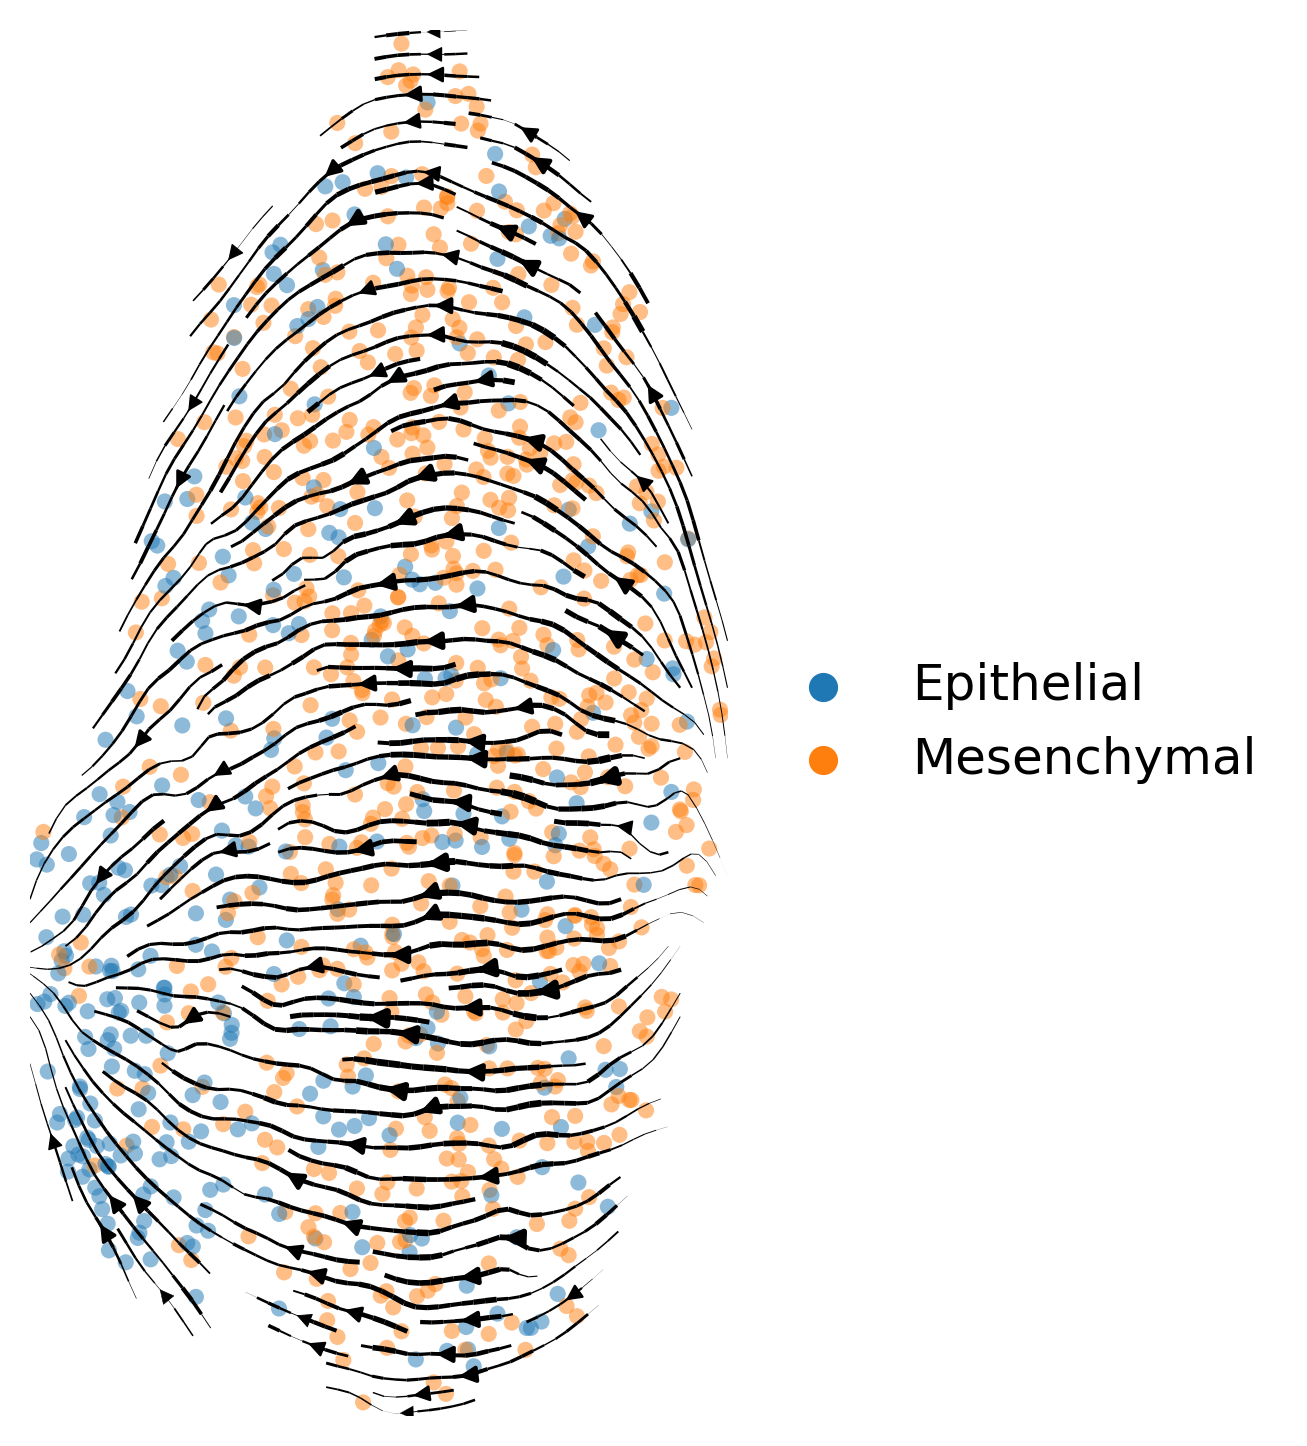

computing velocity graph (using 1/36 cores)


  0%|          | 0/1030 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_umap', embedded velocity vectors (adata.obsm)


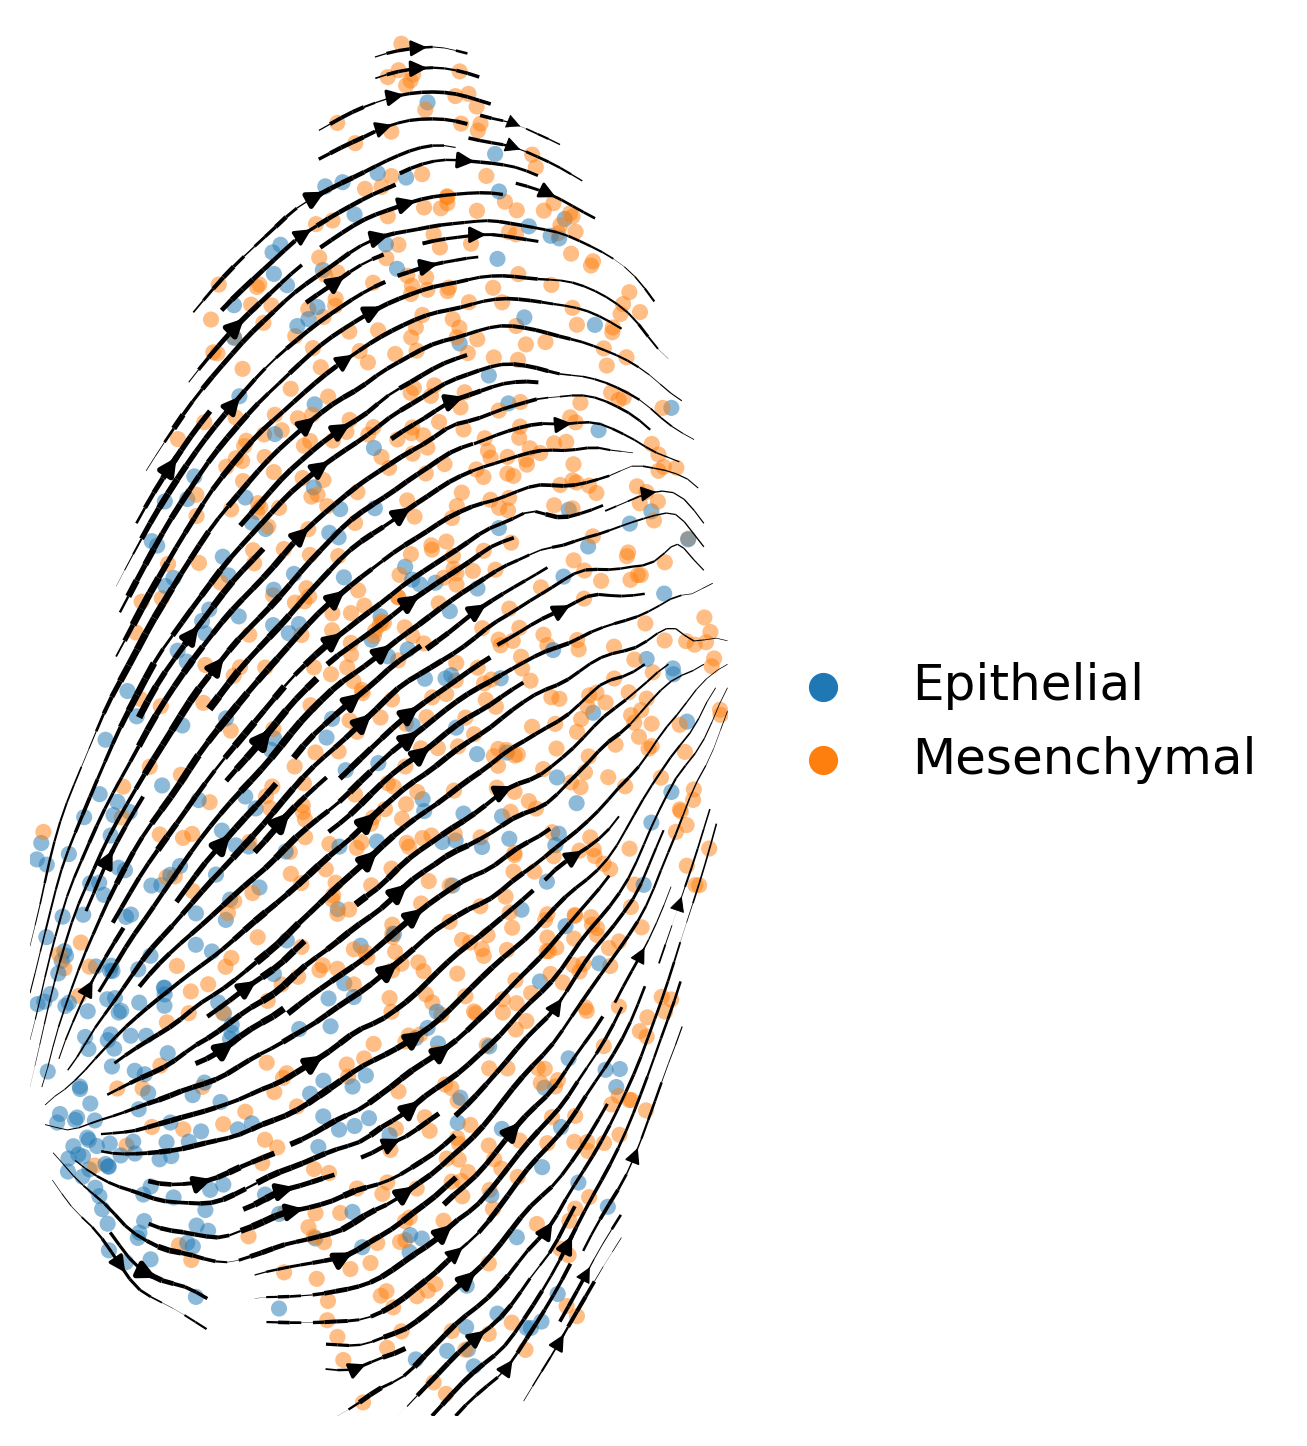

In [15]:
_ = tpv.post_analysis(
    adata,
    'main_brain',
    ['scVelo', 'VeloVAE (Rate Prior)', 'TopoVelo (GAT)'],
    ['fit', 'fullvb', 'gat'],
    spatial_velocity_graph=False,
    plot_basis='umap',
    plot_type=['embed velocity'],
    stream_plot_config=stream_plot_config,
    dpi=300
)